In [3]:
# Import Libraries

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

print("Import Successsful")

2024-04-26 05:14:07.448157: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-26 05:14:07.448309: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-26 05:14:07.636130: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Import Successsful


In [4]:
# Training Data Pre-processing

training_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/fruit-and-vegetable-image-recognition/train',
    labels = 'inferred' ,
    label_mode = 'categorical' ,
    class_names = None ,
    color_mode = 'rgb' ,
    batch_size = 32 ,
    image_size = ( 64 , 64 ) ,
    shuffle = True ,
    seed = None ,
    validation_split = None ,
    subset = None ,
    interpolation = 'bilinear' ,
    follow_links = False ,
    crop_to_aspect_ratio = False
)

Found 3115 files belonging to 36 classes.


In [5]:
# Validation Data Pre-processing

validation_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/fruit-and-vegetable-image-recognition/validation',
    labels = 'inferred' ,
    label_mode = 'categorical' ,
    class_names = None ,
    color_mode = 'rgb' ,
    batch_size = 32 ,
    image_size = ( 64 , 64 ) ,
    shuffle = True ,
    seed = None ,
    validation_split = None ,
    subset = None ,
    interpolation = 'bilinear' ,
    follow_links = False ,
    crop_to_aspect_ratio = False
)

Found 351 files belonging to 36 classes.


In [6]:
# Model Building

cnn = tf.keras.models.Sequential()

In [7]:
# Convolution Layer Building
cnn.add(tf.keras.layers.Input(shape=(64, 64, 3)))
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=2, strides=2))

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=2, strides=2))

In [9]:
cnn.add(tf.keras.layers.Dropout(0.5))  # Parameter added to avoid overfitting
cnn.add(tf.keras.layers.Flatten())

In [10]:
# Building Neural Network

cnn.add( tf.keras.layers.Dense( units = 128, activation = 'relu' ))

# Output Layer

cnn.add( tf.keras.layers.Dense( units = 36 , activation = 'softmax'))

In [11]:
# Compilation

cnn.compile( optimizer = 'rmsprop' , loss = 'categorical_crossentropy' , metrics = ['accuracy'] )


In [12]:
# Training Phase

cnn.fit( x = training_set , validation_data = validation_set , epochs = 30 )

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 81s 741ms/step - accuracy: 0.0427 - loss: 21.7821 - val_accuracy: 0.0912 - val_loss: 3.5141
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 621ms/step - accuracy: 0.0701 - loss: 4.0024 - val_accuracy: 0.1510 - val_loss: 3.1007
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 623ms/step - accuracy: 0.0976 - loss: 4.3525 - val_accuracy: 0.2023 - val_loss: 3.0768
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 81s 611ms/step - accuracy: 0.1381 - loss: 3.4735 - val_accuracy: 0.4046 - val_loss: 2.5604
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 65s 614ms/step - accuracy: 0.1964 - loss: 3.4018 - val_accuracy: 0.0456 - val_loss: 3.5199
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 65s 618ms/step - accuracy: 0.1129 - loss: 3.5886 - val_accuracy: 0.4758 - val_loss: 2.3657
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 632ms/step - accuracy: 0.2278 - loss: 3.1399 - val_accuracy: 0.4160 - val_loss: 2.8746
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 80s 617ms/step - accuracy: 0.3337 - loss: 2.6799 - val_acc

In [13]:
# Saving Model

cnn.save('trained_model.h5')


In [14]:
cnn.history.history

{'accuracy': [0.04141252115368843,
  0.07800962775945663,
  0.10882825404405594,
  0.1428571492433548,
  0.1666131615638733,
  0.16019262373447418,
  0.25072231888771057,
  0.34414124488830566,
  0.3775281012058258,
  0.4337078630924225,
  0.4905296862125397,
  0.5313001871109009,
  0.5611556768417358,
  0.6211878061294556,
  0.6471909880638123,
  0.7075441479682922,
  0.7248796224594116,
  0.7518458962440491,
  0.7592295408248901,
  0.7836276292800903,
  0.8112359642982483,
  0.8311396241188049,
  0.8295345306396484,
  0.838523268699646,
  0.8542535901069641,
  0.8648475408554077,
  0.8764045238494873,
  0.8937399387359619,
  0.8837881088256836,
  0.8834670782089233],
 'loss': [8.306275367736816,
  3.9997003078460693,
  4.3442206382751465,
  3.5213398933410645,
  3.8204259872436523,
  3.4692656993865967,
  3.0487098693847656,
  2.6611554622650146,
  2.5904338359832764,
  2.3875362873077393,
  2.1400346755981445,
  1.918243408203125,
  1.774399757385254,
  1.5555779933929443,
  1.45452

In [15]:
# Record History

import json
with open( 'training_hist.json' , 'w' ) as f :
    json.dump( cnn.history.history , f )

In [16]:
print(cnn.history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [17]:
# Calculating Model Accuracy achieved on validation set 

print("validation Set Accuracy: {} %".format(cnn.history.history['val_accuracy'][-1] * 100 ))

validation Set Accuracy: 92.87749528884888 %


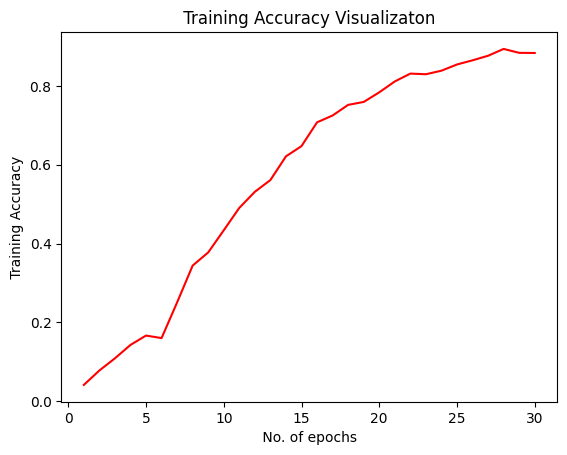

In [24]:
# Accuracy visualization - Training

epochs = [ i for i in range ( 1 , 31 ) ]
plt.plot( epochs , cnn.history.history['accuracy'] , color = 'red' )
plt.title(" Training Accuracy Visualizaton ")
plt.xlabel(" No. of epochs ")
plt.ylabel(" Training Accuracy ")
plt.show()

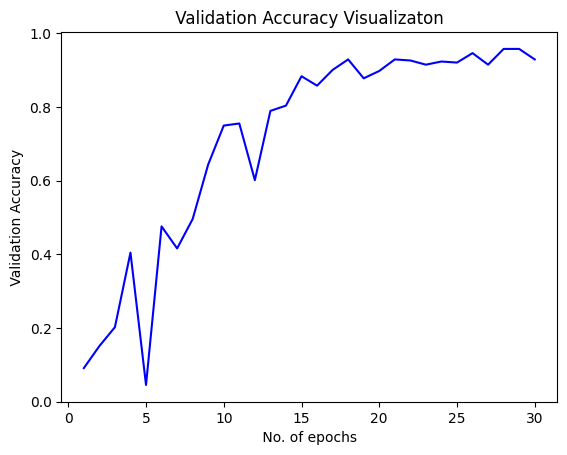

In [25]:
plt.plot( epochs , cnn.history.history['val_accuracy'] , color = 'blue' )
plt.title(" Validation Accuracy Visualizaton ")
plt.xlabel(" No. of epochs ")
plt.ylabel(" Validation Accuracy ")
plt.show()

In [ ]:
# Loading 